<a href="https://colab.research.google.com/github/DWalicki95/MaterialsVision/blob/main/notebooks/cellpose_finetuned_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ['PYTHONPATH'] = (
  '/content/MaterialsVision:' + os.environ.get('PYTHONPATH', '')
)

In [2]:
from pathlib import Path
import numpy as np
from cellpose.io import imread
import tifffile
import time

from cellpose.metrics import (
    mask_ious, boundary_scores, aggregated_jaccard_index, average_precision
)
import torch
from skimage.segmentation import relabel_sequential
from cellpose.metrics import boundary_scores
from cellpose import utils
import gc
import pandas as pd
from typing import Dict, List
import json
import matplotlib.pyplot as plt

from datetime import datetime

In [3]:
dataset_raw_path = Path(
    'test'
  )

In [4]:
import shutil
from pathlib import Path

def prepare_stardist_dataset(src_dir, dst_dir):
    src_dir, dst_dir = Path(src_dir), Path(dst_dir)
    
    # Wyczyść jeśli istnieje
    if dst_dir.exists():
        shutil.rmtree(dst_dir)
    
    (dst_dir/'images').mkdir(parents=True, exist_ok=True)
    (dst_dir/'masks').mkdir(parents=True, exist_ok=True)

    for img in sorted(src_dir.glob('*_image.jpg')):
        new_name = img.stem.replace('_image', '') + img.suffix
        shutil.copy(img, dst_dir/'images'/new_name)

    for msk in sorted(src_dir.glob('*_masks.tif')):
        new_name = msk.stem.replace('_masks', '') + msk.suffix
        shutil.copy(msk, dst_dir/'masks'/new_name)

    X = sorted((dst_dir/'images').glob('*.jpg'))
    Y = sorted((dst_dir/'masks').glob('*.tif'))

    print(f"Znaleziono: {len(X)} obrazów | {len(Y)} masek")  # debug

    assert len(X) == len(Y), f"Różna liczba obrazów i masek w {dst_dir}!"
    assert all(Path(x).stem == Path(y).stem for x, y in zip(X, Y)), "Niedopasowane pary!"
    
    print(f"{dst_dir.name}: {len(X)} par — OK ✓")
    return X, Y

In [5]:
X_test, Y_test = prepare_stardist_dataset(src_dir=dataset_raw_path, dst_dir='stardist-test-data')

Znaleziono: 128 obrazów | 128 masek
stardist-test-data: 128 par — OK ✓


# Model evaluation

In [6]:
def get_bbox_from_mask(mask: np.ndarray, relabel_image: bool = True) -> dict:
  if relabel_image:
    mask, forward, inverse_map = relabel_sequential(mask, offset=1)
  labels = np.unique(mask)
  bboxes = {}
  for label in labels[labels>0]:
    rows, cols = np.where(mask==label)
    if rows.size == 0:
      continue
    y_min, y_max = rows.min(), rows.max()
    x_min, x_max = cols.min(), cols.max()
    bboxes[int(label)] = int(x_min), int(y_min), int(x_max), int(y_max)
  return bboxes

In [7]:
def get_n_pores_from_mask(mask: np.ndarray):
  labels = np.unique(mask)
  n_pores = len(labels) - (1 if 0 in labels else 0)
  return n_pores

In [8]:
def calculate_iou(bbox_true, bbox_pred, epsilon=1e-5):
  # coordinates of the intersection box
  x1 = np.max([bbox_true[0], bbox_pred[0]])
  y1 = np.max([bbox_true[1], bbox_pred[1]])
  x2 = np.min([bbox_true[2], bbox_pred[2]])
  y2 = np.min([bbox_true[3], bbox_pred[3]])

  # area of overlap
  width = (x2 - x1)
  height = (y2 - y1)

  # if there is no overlap
  if (width<0) or (height<0):
    return 0.0
  area_of_overlap = width * height
  # combined area
  area_bbox_true = (bbox_true[2] - bbox_true[0]) * (bbox_true[3] - bbox_true[1])
  area_bbox_pred = (bbox_pred[2] - bbox_pred[0]) * (bbox_pred[3] - bbox_pred[1])
  area_combined = area_bbox_true + area_bbox_pred - area_of_overlap
  # ratio of area of overlap over combined area
  iou = area_of_overlap / (area_combined + epsilon)
  return iou

In [9]:
def get_iou_matrix(bboxes_true, bboxes_pred):
  n_bboxes_true = len(bboxes_true)
  n_bboxes_pred = len(bboxes_pred)
  I = np.zeros((n_bboxes_true, n_bboxes_pred), dtype=np.float32)
  for i in range(n_bboxes_true):
    for j in range(n_bboxes_pred):
      I[i, j] = calculate_iou(bboxes_true[i], bboxes_pred[j])
  return I

In [10]:
def calculate_pores_difference(n_pores_true: int, n_pores_pred):
  return float(np.abs(n_pores_true - n_pores_pred) / n_pores_true)

In [11]:
def greedy_match_iou(iou_matrix, threshold):
  I = iou_matrix.copy()
  all_triples_list = []
  matched_true, matched_pred = set(), set()
  matches = []
  I[I < threshold] = 0.0
  N_true, N_pred = I.shape
  # get pores difference
  pores_diff = calculate_pores_difference(N_true, N_pred)

  non_zero = np.argwhere(I>0.0)
  for (i, j) in non_zero:
    all_triples_list.append((i, j, I[i, j]))

  sorted_all_triples_list = sorted(
      all_triples_list, key=lambda x: x[2], reverse=True
  )

  for triples in sorted_all_triples_list:
    if (triples[0] not in matched_true) & (triples[1] not in matched_pred):
      matched_true.add(triples[0])
      matched_pred.add(triples[1])
      matches.append((triples[0], triples[1], triples[2]))

  TP = len(matches)
  FN = N_true - len(matched_true)
  FP = N_pred - len(matched_pred)

  precision = (TP / (TP + FP) if (TP + FP) > 0 else 0.0)
  recall = (TP / (TP + FN) if (TP+FN) > 0 else 0.0)
  f1_score = (2 * (precision * recall) / (precision + recall) if
      (precision + recall) > 0 else 0.0
  )
  iou_mean = float(
      sum(score for (_, _, score) in matches) / TP if TP > 0 else 0.0
    )

  return {
      'TP': TP,
      'FP': FP,
      'FN': FN,
      'precision': precision,
      'recall': recall,
      'f1_score': f1_score,
      'iou_mean': iou_mean,
      'pores_diff': pores_diff
  }


In [12]:
def iou_scores_batch(true_masks, pred_masks, greedy_match_threshold = 0.5):
  iou_results = {}
  for idx, (true_mask, pred_mask) in enumerate(zip(true_masks, pred_masks)):
    pred_bboxes = get_bbox_from_mask(pred_mask)
    true_bboxes = get_bbox_from_mask(true_mask)
    iou_matrix = get_iou_matrix(
        list(pred_bboxes.values()), list(true_bboxes.values())
    )
    one_img_output = greedy_match_iou(iou_matrix, greedy_match_threshold)
    iou_results[idx] = one_img_output
  return iou_results

In [13]:
def boundary_scores_batched(masks_true, masks_pred, scales, batch_size=2):
    N = len(masks_true)
    M = len(scales)

    precision_all = np.zeros((M, N), dtype=float)
    recall_all    = np.zeros((M, N), dtype=float)
    fscore_all    = np.zeros((M, N), dtype=float)

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        # part of lists (batched solution)
        sub_true = masks_true[start:end]
        sub_pred = masks_pred[start:end]
        p_sub, r_sub, f_sub = boundary_scores(sub_true, sub_pred, scales)

        precision_all[:, start:end] = p_sub
        recall_all[:, start:end]    = r_sub
        fscore_all[:, start:end]    = f_sub

        # clean memory
        gc.collect()

    return precision_all, recall_all, fscore_all


In [14]:
def summarize_evaluation_iou(iou_results):
    TP_all, FP_all, FN_all = [], [], []
    micro_metrics = ['TP', 'FP', 'FN']

    # Identify macro metrics
    macro_metrics_list = [
        metric for metric in list(iou_results.values())[0].keys()
        if metric not in micro_metrics
    ]

    # Initialize collectors for macro metrics
    macro_values = {metric: [] for metric in macro_metrics_list}

    # Collect values from all images
    for metric_dict in iou_results.values():
        for metric, value in metric_dict.items():
            if metric in macro_metrics_list:
                macro_values[metric].append(value)
            elif metric == 'TP':
                TP_all.append(value)
            elif metric == 'FP':
                FP_all.append(value)
            elif metric == 'FN':
                FN_all.append(value)

    # Calculate macro averages
    macro_metric_results = {}
    for metric, values in macro_values.items():
        macro_metric_results[f'iou_mean_{metric}'] = np.mean(values)

    # Calculate micro metrics
    TP_all_sum = np.sum(TP_all)
    FP_all_sum = np.sum(FP_all)
    FN_all_sum = np.sum(FN_all)

    precision_micro = TP_all_sum / (
        TP_all_sum + FP_all_sum) if (TP_all_sum + FP_all_sum) > 0 else 0
    recall_micro = TP_all_sum / (
        TP_all_sum + FN_all_sum) if (TP_all_sum + FN_all_sum) > 0 else 0
    f1_micro = (
        2 * precision_micro * recall_micro
    ) / (
          precision_micro + recall_micro
        ) if (precision_micro + recall_micro) > 0 else 0

    # Prepare final report
    report = pd.DataFrame.from_dict(
        macro_metric_results, orient='index', columns=['value']
    )
    report.loc['iou_precision_micro'] = precision_micro
    report.loc['iou_recall_micro'] = recall_micro
    report.loc['iou_f1_micro'] = f1_micro

    return report

In [15]:
def summarize_evaluation_boundary_score(precision_all, recall_all, fscore_all):
  bs_precision_mean = np.mean(precision_all)
  bs_recall_mean = np.mean(recall_all)
  bs_fscore_mean = np.mean(fscore_all)
  bs_metrics_dict = {
        'boundary_score_mean_precision': bs_precision_mean,
        'boundary_score_mean_recall':    bs_recall_mean,
        'boundary_score_mean_f1':        bs_fscore_mean,
  }
  report = pd.DataFrame.from_dict(
      bs_metrics_dict, orient='index', columns=['value']
  )
  return report

In [16]:
def get_today_datetime_str():
  today_datetime = datetime.now().strftime("%m/%d/%Y %H:%M:%S")
  today_datetime = today_datetime[:-3]  # skip seconds
  today_datetime = (
      today_datetime
      .replace('-', '_')
      .replace(':', '_')
      .replace('/', '_')
      .replace(' ', '__')
  )
  return today_datetime

In [17]:
def summarize_evaluation(
    output_filename: str,
    model_params: Dict,
    evaluating_duration: float,
    iou_results: Dict,
    boundary_score_precision_all: List,
    boundary_score_recall_all: List,
    boundary_score_fscore_all: List,
    evaluation_comment: str = '',
    save_raw_iou_results: bool = True,
    save_final_results: bool = True,
    output_directory_path = None,
    add_today_datetime_to_filename: bool = True
):
  report_iou = summarize_evaluation_iou(iou_results)
  report_boundary_score = summarize_evaluation_boundary_score(
      precision_all=boundary_score_precision_all,
      recall_all=boundary_score_recall_all,
      fscore_all=boundary_score_fscore_all
  )
  report_final = pd.concat([report_iou, report_boundary_score])
  report_final['comment'] = evaluation_comment
  report_final['model_params'] = [model_params] * len(report_final)
  report_final['evaluation_duration'] = evaluating_duration
  # save files
  today_datetime_str = (
      get_today_datetime_str() if add_today_datetime_to_filename else ''
  )
  if not output_directory_path:
    output_directory_path = Path(
        '/content/drive/MyDrive/evaluation_metrics'
    )
  # save raw iou
  if save_raw_iou_results:
    output_directory_path.mkdir(parents=True, exist_ok=True)
    output_filename = (
        f'raw_iou_results_{evaluation_comment}_{today_datetime_str}.json'
    )
    output_filepath = output_directory_path / output_filename
    with open(output_filepath, 'w') as f:
      json.dump(iou_results, f)
    print('Raw iou test dictionary saved.')
  # save final results
  if save_final_results:
    output_directory_path.mkdir(parents=True, exist_ok=True)
    output_filename = (
        f'evaluation_results_{today_datetime_str}.csv'
    )
    output_filepath = output_directory_path / output_filename
    report_final.to_csv(output_filepath)
    print('Final evaluation metrics report saved.')
    return report_final

In [18]:
def visualize_results(
    imgs,
    pred_masks,
    flows,
    img_idx_to_visualize: int = 0,
    save_subsample: bool = True,
    output_directory_path = None,
    add_today_datetime_to_filename: bool = True,
    evaluation_comment: str = ''
):
  if not output_directory_path:
    output_directory_path = Path(
        '/content/drive/MyDrive/evaluation_metrics/plots'
    )
  today_datetime_str = (
      get_today_datetime_str() if add_today_datetime_to_filename else ''
  )
  # save images
  if save_subsample:
    output_directory_path.mkdir(parents=True, exist_ok=True)
    num_images = 10
    for img_idx in range(num_images):
        fig = plt.figure(figsize=(20, 12))
        plot.show_segmentation(
          fig=fig,
          maski=pred_masks[img_idx],
          img=imgs[img_idx],
          flowi=flows[img_idx][0]
        )
        plt.savefig(
            f'{output_directory_path}/{evaluation_comment}_figure_{img_idx}.jpg'
        )
        plt.close(fig)
  # show_figure
  fig = plt.figure(figsize=(30, 20))
  plot.show_segmentation(
    fig=fig,
    maski=pred_masks[img_idx_to_visualize],
    img=imgs[img_idx_to_visualize],
    flowi=flows[img_idx_to_visualize][0]
  )
  plt.show()

# Evaluation

In [19]:
from stardist.models import StarDist2D
from csbdeep.utils import normalize
from tifffile import imread
import matplotlib.pyplot as plt

I0000 00:00:1778234303.393027     130 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778234303.455181     130 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778234304.683136     130 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [22]:
MODEL_BASEDIR = Path('stardist-models')
MODEL_PATH = MODEL_BASEDIR / 'weights_final.h5'
MODEL_CONFIG = MODEL_BASEDIR / 'config.json'

In [23]:
import tensorflow as tf
import keras
import stardist
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"StarDist: {stardist.__version__}")
print(f"\nMODEL_BASEDIR: {MODEL_BASEDIR.absolute()}")

# Sprawdź też zawartość folderu
for f in sorted(Path(MODEL_BASEDIR / 'stardist').iterdir()):
    print(f"  {f.name}: {f.stat().st_size / 1e6:.2f} MB")

TensorFlow: 2.21.0
Keras: 3.14.1
StarDist: 0.9.2

MODEL_BASEDIR: /app/stardist-models
  .ipynb_checkpoints: 0.00 MB
  Untitled.ipynb: 0.00 MB
  config.json: 0.00 MB
  thresholds.json: 0.00 MB
  weights_best.h5: 16.08 MB
  weights_best_OLD.h5: 5.77 MB
  weights_final.h5: 16.08 MB
  weights_last.h5: 16.08 MB


In [24]:
model = StarDist2D(None, name='stardist', basedir=MODEL_BASEDIR)

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479347, nms_thresh=0.3.


In [25]:
from skimage.io import imread as sk_imread
X_test = list(map(sk_imread,X_test))
Y_test = list(map(imread,Y_test))
n_channel = 1 if X_test[0].ndim == 2 else X_test[0].shape[-1]

In [26]:
from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist.matching import matching, matching_dataset
from stardist.models import Config2D, StarDist2D, StarDistData2D


In [27]:
import sys
from tqdm import tqdm
axis_norm = (0,1)   # normalize channels independently
# axis_norm = (0,1,2) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 2 in axis_norm else 'independently'))
    sys.stdout.flush()

X_test = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X_test)]
Y_test = [fill_label_holes(y) for y in tqdm(Y_test)]

Normalizing image channels independently.


100%|███████████████████████████████████████████████████████████████| 128/128 [00:02<00:00, 48.09it/s]


In [28]:
true_masks = [imread(img_path) for img_path in list(dataset_raw_path.glob('*_masks.tif'))]

In [27]:
# true_masks = [x['true_mask'] for x in dataset]
# pred_masks = [x['pred_mask'] for x in dataset]

In [29]:
i = 0
x_input = X_test[i][:, :, 0]
prob, dist = model.predict(x_input, n_tiles=model._guess_n_tiles(x_input))
print(f"Prob max: {prob.max():.3f}")   # Oczekuję > 0.8 dla zdrowego modelu

I0000 00:00:1778234538.661978     255 service.cc:153] XLA service 0x7bc62c032f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778234538.662013     255 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5090, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1778234538.703777     255 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778234538.814531     255 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1778234539.710174     255 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|███████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.46it/s]

Prob max: 0.933


In [30]:
Y_pred = []

for i, x in enumerate(X_test):
    x_input = x[:, :, 0]   # 2D (H, W) — TAK JAK W TRENINGU

    labels, details = model.predict_instances(
        x_input,
        n_tiles=model._guess_n_tiles(x_input),
        show_tile_progress=False,
    )

    Y_pred.append(labels)
    print(f'Obraz {i+1}/{len(X_test)}: wykryto {labels.max()} obiektów')

Obraz 1/128: wykryto 66 obiektów
Obraz 2/128: wykryto 55 obiektów
Obraz 3/128: wykryto 50 obiektów
Obraz 4/128: wykryto 62 obiektów
Obraz 5/128: wykryto 40 obiektów
Obraz 6/128: wykryto 36 obiektów
Obraz 7/128: wykryto 40 obiektów
Obraz 8/128: wykryto 31 obiektów
Obraz 9/128: wykryto 43 obiektów
Obraz 10/128: wykryto 46 obiektów
Obraz 11/128: wykryto 25 obiektów
Obraz 12/128: wykryto 46 obiektów
Obraz 13/128: wykryto 33 obiektów
Obraz 14/128: wykryto 38 obiektów
Obraz 15/128: wykryto 38 obiektów
Obraz 16/128: wykryto 37 obiektów
Obraz 17/128: wykryto 40 obiektów
Obraz 18/128: wykryto 39 obiektów
Obraz 19/128: wykryto 48 obiektów
Obraz 20/128: wykryto 38 obiektów
Obraz 21/128: wykryto 33 obiektów
Obraz 22/128: wykryto 30 obiektów
Obraz 23/128: wykryto 29 obiektów
Obraz 24/128: wykryto 46 obiektów
Obraz 25/128: wykryto 44 obiektów
Obraz 26/128: wykryto 44 obiektów
Obraz 27/128: wykryto 37 obiektów
Obraz 28/128: wykryto 40 obiektów
Obraz 29/128: wykryto 40 obiektów
Obraz 30/128: wykryto 4

In [31]:
iou_results = iou_scores_batch(
    true_masks=Y_test,
    pred_masks=Y_pred,
    greedy_match_threshold=0.5
)

In [34]:
def check_mask_shapes(true_masks, pred_masks):
    """Check for shape mismatches between true and predicted masks."""
    mismatches = []

    for i, (true_mask, pred_mask) in enumerate(zip(true_masks, pred_masks)):
        if true_mask.shape != pred_mask.shape:
            mismatches.append({
                'index': i,
                'true_shape': true_mask.shape,
                'pred_shape': pred_mask.shape
            })

    if mismatches:
        print(f"Found {len(mismatches)} shape mismatches:")
        for m in mismatches[:10]:  # Show first 10
            print(f"  Index {m['index']}: true={m['true_shape']}, pred={m['pred_shape']}")
    else:
        print("✓ All masks have matching shapes!")

    return mismatches

# Check your data
mismatches = check_mask_shapes(true_masks, Y_pred)

✓ All masks have matching shapes!


In [35]:
import numpy as np

def align_mask_shapes(mask1, mask2):
    """
    Align two masks to the same shape by cropping to minimum dimensions.

    Parameters:
    -----------
    mask1, mask2 : np.ndarray
        Masks to align

    Returns:
    --------
    mask1_aligned, mask2_aligned : np.ndarray
        Masks with matching shapes
    """
    h1, w1 = mask1.shape
    h2, w2 = mask2.shape

    # Use minimum dimensions
    min_h = min(h1, h2)
    min_w = min(w1, w2)

    # Crop both masks to minimum size
    mask1_aligned = mask1[:min_h, :min_w]
    mask2_aligned = mask2[:min_h, :min_w]

    return mask1_aligned, mask2_aligned

In [36]:
bs_precision_all, bs_recall_all, bs_fscore_all = boundary_scores_batched(
    Y_test,
    Y_pred,
    scales=[0.2],
    batch_size=16

)

In [37]:
summarize_evaluation(
    output_filename='stardist-initial-finetuning',
    output_directory_path=Path('results'),
    iou_results=iou_results,
    boundary_score_precision_all=bs_precision_all,
    boundary_score_recall_all=bs_recall_all,
    boundary_score_fscore_all=bs_fscore_all,
    evaluation_comment='stardist-initial-finetuning -- AS1 only dataset',
    save_raw_iou_results=True,
    save_final_results=True,
    model_params={},
    evaluating_duration=1,
    add_today_datetime_to_filename=True
)

Raw iou test dictionary saved.
Final evaluation metrics report saved.


,value,comment,model_params,evaluation_duration
iou_mean_precision,0.832222,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_mean_recall,0.737249,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_mean_f1_score,0.774707,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_mean_iou_mean,0.817559,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_mean_pores_diff,0.141215,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_precision_micro,0.841831,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_recall_micro,0.751870,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_f1_micro,0.794311,stardist-initial-finetuning -- AS1 only dataset,{},1
boundary_score_mean_precision,0.768810,stardist-initial-finetuning -- AS1 only dataset,{},1
boundary_score_mean_recall,0.892492,stardist-initial-finetuning -- AS1 only dataset,{},1


100%|███████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 14.59it/s]


Predykcja: 66 | GT: 35


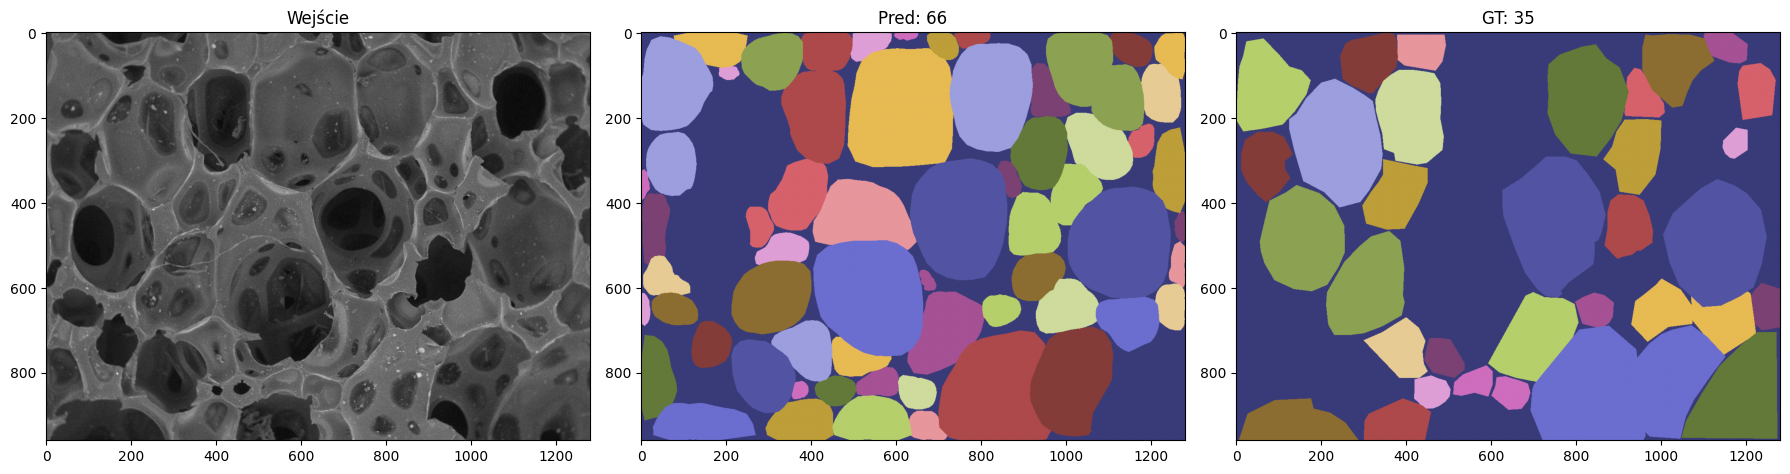

In [38]:
import matplotlib.pyplot as plt

i = 0
x_input = X_test[i][:, :, 0]
labels, _ = model.predict_instances(x_input, n_tiles=model._guess_n_tiles(x_input))

print(f"Predykcja: {labels.max()} | GT: {Y_test[i].max()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(x_input, cmap='gray'); axes[0].set_title('Wejście')
axes[1].imshow(labels, cmap='tab20b'); axes[1].set_title(f'Pred: {labels.max()}')
axes[2].imshow(Y_test[i], cmap='tab20b'); axes[2].set_title(f'GT: {Y_test[i].max()}')
plt.tight_layout()
plt.show()

In [33]:
from pathlib import Path
import tifffile

# Odtwórz posortowane ścieżki obrazów (ten sam sorted co w prepare_stardist_dataset)
image_paths = sorted(Path('stardist-test-data/images').glob('*.jpg'))

assert len(image_paths) == len(Y_pred), \
    f"Liczba obrazów ({len(image_paths)}) ≠ predykcji ({len(Y_pred)})"

# Zapisz maski predykcji
save_dir = Path('stardist-test-data/pred_masks')
save_dir.mkdir(exist_ok=True)

for img_path, mask in zip(image_paths, Y_pred):
    save_path = save_dir / f"{img_path.stem}.tif"  # ta sama nazwa co GT w /masks/
    tifffile.imwrite(save_path, mask.astype(np.int32))

print(f"✅ Zapisano {len(Y_pred)} masek → {save_dir}/")

✅ Zapisano 128 masek → stardist-test-data/pred_masks/
